# 🫁 Updated Hybrid Framework for Pneumonia Detection in Chest X-Ray Images

**Architecture Overview:**
- **Branch 1:** ShuffleNetV2 + ECA (Efficient Channel Attention) — lightweight, fine-grained local features
- **Branch 2:** EfficientNet-B0 + CBAM (Convolutional Block Attention Module) — global semantic + spatial features
- **LAMR Module:** Lesion-Aware Multi-scale Refinement (inspired by multi-scale nodule detection)
- **Grad-CAM:** Interpretability visualization for clinical reliability

> Dataset: [Chest X-ray Pneumonia (Kaggle)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)

---
**Update notes (this revision):**
- Added the missing `EfficientNetB0_CBAM` branch class — the notebook previously referenced it when building `HybridPneumoniaNet` and in the complexity analysis, but it was never defined, so model construction would fail.
- Collapsed three separate, slightly-different dataset-loading cells into a single consistent one (removes redundant work and avoids leftover variables from earlier attempts shadowing later ones).
- Removed a stray duplicate `pip install timm` cell and a leftover exploratory `timm.list_models()` cell.
- Minor cleanups so cell execution order is consistent (e.g. `counts` used by the class-weight cell is now produced in the same cell that builds the datasets).


## 1. Install & Import Dependencies

In [1]:
# ── Install any missing packages ──────────────────────────────────────────────
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

for _pkg in ['timm', 'grad-cam', 'albumentations', 'torchinfo', 'thop']:
    pip_install(_pkg)

print('All packages ready.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.2 MB/s eta 0:00:00
All packages ready.


In [2]:
# ── Standard imports ──────────────────────────────────────────────────────────
import os, random, warnings, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as tv_models
import timm

# ── Sklearn metrics ───────────────────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)

# ── Grad-CAM ──────────────────────────────────────────────────────────────────
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ── Albumentations ────────────────────────────────────────────────────────────
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 2. Configuration

In [3]:
# ── Hyper-parameters & paths ─────────────────────────────────────────────────
class CFG:
    # ── Dataset paths (Kaggle environment) ────────────────────────────────────
    DATA_DIR   = Path('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia')
    TRAIN_DIR  = DATA_DIR / 'train'
    VAL_DIR    = DATA_DIR / 'val'
    TEST_DIR   = DATA_DIR / 'test'

    # ── Image ─────────────────────────────────────────────────────────────────
    IMG_SIZE   = 224          # both branches expect 224×224
    IN_CHANS   = 3

    # ── Training ──────────────────────────────────────────────────────────────
    BATCH_SIZE = 32
    EPOCHS     = 30
    LR         = 3e-4
    WEIGHT_DECAY = 1e-4
    NUM_WORKERS  = 4

    # ── Model ─────────────────────────────────────────────────────────────────
    NUM_CLASSES   = 2          # NORMAL / PNEUMONIA
    FUSION_DIM    = 256        # after projection
    LAMR_CHANNELS = 256        # LAMR internal channels

    # ── Class labels ──────────────────────────────────────────────────────────
    CLASSES = ['NORMAL', 'PNEUMONIA']

    # ── Checkpoint ────────────────────────────────────────────────────────────
    CKPT_PATH = '/kaggle/working/best_model.pth'

cfg = CFG()
print('Configuration loaded.')

Configuration loaded.


## Prepare Train / Val / Test Split\n\nRe-splits the raw Kaggle release (which ships with a tiny 16-image `val` folder) into proper 70/15/15 train/val/test folders under `/kaggle/working/`.

In [4]:
import shutil
from sklearn.model_selection import train_test_split

base_path   = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'
output_path = '/kaggle/working/chest_xray_split'
classes     = ['NORMAL', 'PNEUMONIA']

for split in ['train', 'val', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

all_images = {cls: [] for cls in classes}
for split in ['train', 'val', 'test']:
    for cls in classes:
        folder = os.path.join(base_path, split, cls)
        if not os.path.isdir(folder):
            continue
        for img in os.listdir(folder):
            fp = os.path.join(folder, img)
            if os.path.isfile(fp):
                all_images[cls].append(fp)

for cls in classes:
    imgs = all_images[cls]
    random.shuffle(imgs)
    tr, tmp = train_test_split(imgs, test_size=0.30, random_state=42)
    va, te  = train_test_split(tmp,  test_size=0.50, random_state=42)
    for sname, sfiles in zip(['train', 'val', 'test'], [tr, va, te]):
        for fp in sfiles:
            dst = os.path.join(output_path, sname, cls, os.path.basename(fp))
            if not os.path.exists(dst):
                shutil.copy(fp, dst)

print('Dataset split complete.')

Dataset split complete.


## 3. Dataset & Data Augmentation

In [5]:
# ── Albumentations transforms ──────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_train_transforms():
    return A.Compose([
        A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.1),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=15, border_mode=0, p=0.5),
        A.GaussNoise(p=0.3),
        A.CoarseDropout(num_holes_range=(1, 8), hole_height_range=(8, 16), hole_width_range=(8, 16), p=0.3),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])

def get_val_transforms():
    return A.Compose([
        A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])


# ── Dataset that verifies image integrity and skips corrupted files ───────────
class ChestXRayDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []
        self.label_map = {cls: i for i, cls in enumerate(cfg.CLASSES)}

        if not self.root_dir.exists():
            raise FileNotFoundError(f'Directory not found: {self.root_dir}')

        bad_files = 0
        for cls in cfg.CLASSES:
            cls_dir = self.root_dir / cls
            if not cls_dir.exists():
                print(f'[WARNING] Missing folder: {cls_dir}')
                continue
            count = 0
            for img_path in cls_dir.rglob('*'):
                if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
                    continue
                try:
                    with Image.open(img_path) as img:
                        img.verify()
                    self.samples.append((img_path, self.label_map[cls]))
                    count += 1
                except Exception:
                    bad_files += 1
            print(f'  {cls}: {count} valid images')

        print(f'Loaded {len(self.samples)} images from {self.root_dir}  (skipped {bad_files} corrupted)')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = np.array(Image.open(img_path).convert('RGB'))
        except Exception:
            # fallback if an image becomes unreadable at read time
            return self.__getitem__(np.random.randint(len(self.samples)))
        if self.transform:
            image = self.transform(image=image)['image']
        return image, label


# ── Build datasets & loaders ───────────────────────────────────────────────────
print('Building datasets...')
train_dataset = ChestXRayDataset(os.path.join(output_path, 'train'), transform=get_train_transforms())
val_dataset   = ChestXRayDataset(os.path.join(output_path, 'val'),   transform=get_val_transforms())
test_dataset  = ChestXRayDataset(os.path.join(output_path, 'test'),  transform=get_val_transforms())

assert len(train_dataset) > 0, 'Training dataset is empty!'
assert len(val_dataset)   > 0, 'Validation dataset is empty!'
assert len(test_dataset)  > 0, 'Test dataset is empty!'

print('\nDataset sizes')
print(f'  Train: {len(train_dataset)}')
print(f'  Val  : {len(val_dataset)}')
print(f'  Test : {len(test_dataset)}')

# drop_last=True avoids a final batch of size 1, which would crash BatchNorm1d
# layers in the model heads during training (they need >1 sample per channel).
train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True,
                           num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=cfg.BATCH_SIZE, shuffle=False,
                           num_workers=cfg.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=cfg.BATCH_SIZE, shuffle=False,
                           num_workers=cfg.NUM_WORKERS, pin_memory=True)

# ── Class distribution (also used later for class-weighted loss) ─────────────
train_labels = [label for _, label in train_dataset.samples]
unique, counts = np.unique(train_labels, return_counts=True)

print('\nTraining class distribution')
for u, c in zip(unique, counts):
    print(f'  {cfg.CLASSES[u]}: {c}')

Building datasets...
  NORMAL: 1108 valid images
  PNEUMONIA: 2991 valid images
Loaded 4099 images from /kaggle/working/chest_xray_split/train  (skipped 0 corrupted)
  NORMAL: 237 valid images
  PNEUMONIA: 641 valid images
Loaded 878 images from /kaggle/working/chest_xray_split/val  (skipped 0 corrupted)
  NORMAL: 238 valid images
  PNEUMONIA: 641 valid images
Loaded 879 images from /kaggle/working/chest_xray_split/test  (skipped 0 corrupted)

Dataset sizes
  Train: 4099
  Val  : 878
  Test : 879

Training class distribution
  NORMAL: 1108
  PNEUMONIA: 2991


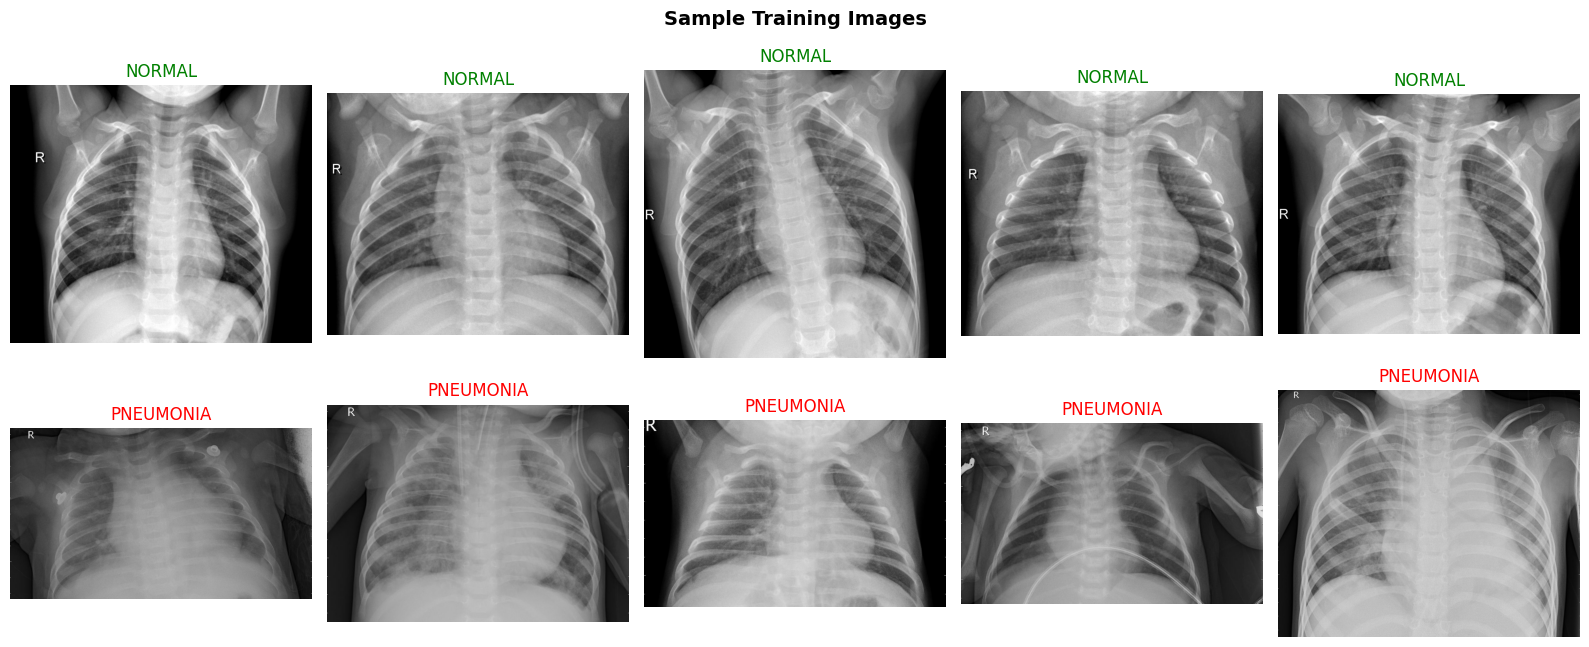

In [6]:
# ── Visualise sample images ───────────────────────────────────────────────────
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample Training Images', fontsize=14, fontweight='bold')

for cls_idx, cls_name in enumerate(cfg.CLASSES):
    cls_samples = [(p, l) for p, l in train_dataset.samples if l == cls_idx]
    for i in range(5):
        img_path, _ = random.choice(cls_samples)
        img = np.array(Image.open(img_path).convert('RGB'))
        axes[cls_idx, i].imshow(img, cmap='gray' if img.mean(axis=2).std() < 10 else None)
        axes[cls_idx, i].set_title(cls_name, color='green' if cls_idx == 0 else 'red')
        axes[cls_idx, i].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=150)
plt.show()

## 4. Attention Modules: ECA, CBAM

In [7]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  ECA — Efficient Channel Attention                                          ║
# ║  Wang et al. (2020) CVPR                                                    ║
# ║  Replaces FC bottleneck with a lightweight 1-D convolution across channels  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
class ECA(nn.Module):
    """
    Efficient Channel Attention.
    Kernel size k is adaptively determined from the number of channels C.
    """
    def __init__(self, channels: int, gamma: int = 2, b: int = 1):
        super().__init__()
        # Adaptive kernel size
        t  = int(abs(math.log2(channels) / gamma + b / gamma))
        k  = t if t % 2 else t + 1
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=k,
                                  padding=k // 2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W)
        y = self.avg_pool(x)            # (B, C, 1, 1)
        y = y.squeeze(-1).transpose(-1, -2)  # (B, 1, C)
        y = self.conv(y)                # (B, 1, C)
        y = y.transpose(-1, -2).unsqueeze(-1)  # (B, C, 1, 1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CBAM — Convolutional Block Attention Module                                ║
# ║  Woo et al. (2018) ECCV                                                     ║
# ║  Sequential channel attention → spatial attention                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
class ChannelAttention(nn.Module):
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        reduced = max(channels // reduction, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.shared_mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = self.shared_mlp(self.avg_pool(x))
        max_out = self.shared_mlp(self.max_pool(x))
        out     = self.sigmoid(avg_out + max_out)
        return x * out.unsqueeze(-1).unsqueeze(-1)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size,
                                 padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.max(dim=1, keepdim=True).values
        out     = torch.cat([avg_out, max_out], dim=1)
        out     = self.sigmoid(self.conv(out))
        return x * out


class CBAM(nn.Module):
    """Channel → Spatial attention block."""
    def __init__(self, channels: int, reduction: int = 16, spatial_k: int = 7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(spatial_k)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.ca(x)
        x = self.sa(x)
        return x


print('ECA and CBAM modules defined.')

ECA and CBAM modules defined.


## 5. LAMR — Lesion-Aware Multi-scale Refinement Module

In [8]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  LAMR — Lesion-Aware Multi-scale Refinement                                 ║
# ║                                                                              ║
# ║  Inspired by the HPFF (Hierarchical Progressive Feature Fusion) and GCSAM   ║
# ║  ideas in Li et al. (2025) for lung nodule detection.                        ║
# ║                                                                              ║
# ║  Three parallel convolution streams (1×1, 3×3, 5×5) capture lesion          ║
# ║  patterns at different receptive fields, then a channel-wise                 ║
# ║  attention gate produces a lesion-sensitive mask to refine the fused         ║
# ║  feature map.                                                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
class LAMRBlock(nn.Module):
    """
    Lesion-Aware Multi-scale Refinement block.

    Args:
        in_channels  : number of input channels (= fusion feature size after projection)
        out_channels : number of output channels
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        mid = out_channels // 4  # internal bottleneck

        # ── Multi-scale parallel branches ──────────────────────────────────────
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, mid, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, mid, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True),
            nn.Conv2d(mid, mid, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        self.branch5 = nn.Sequential(
            nn.Conv2d(in_channels, mid, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True),
            nn.Conv2d(mid, mid, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        # ── Global context (avg-pool) branch ───────────────────────────────────
        self.branch_global = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, mid, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )

        concat_ch = mid * 4          # 4 branches

        # ── Projection to out_channels ─────────────────────────────────────────
        self.proj = nn.Sequential(
            nn.Conv2d(concat_ch, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )

        # ── Lesion-sensitive attention gate (channel-wise) ─────────────────────
        self.gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_channels, out_channels // 4, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels // 4, out_channels, kernel_size=1),
            nn.Sigmoid()
        )

        # ── Residual shortcut (adjust channels if needed) ──────────────────────
        self.shortcut = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape

        b1 = self.branch1(x)                     # (B, mid, H, W)
        b3 = self.branch3(x)                     # (B, mid, H, W)
        b5 = self.branch5(x)                     # (B, mid, H, W)
        bg = self.branch_global(x).expand(B, -1, H, W)  # broadcast

        ms = torch.cat([b1, b3, b5, bg], dim=1)  # (B, 4*mid, H, W)
        ms = self.proj(ms)                        # (B, out_channels, H, W)

        # ── Apply lesion attention gate ────────────────────────────────────────
        gate_w = self.gate(ms)                    # (B, out_channels, 1, 1)
        ms     = ms * gate_w                      # element-wise scale

        return ms + self.shortcut(x)              # residual addition


print('LAMR block defined.')

LAMR block defined.


## 6. Branch Backbones: ShuffleNetV2 + ECA and EfficientNet-B0 + CBAM

In [9]:
# ============================================================
# Branch 1: ShuffleNetV2 + ECA  (torchvision backbone)
# ============================================================
class ShuffleNetV2_ECA(nn.Module):
    """
    Branch 1: Torchvision ShuffleNetV2 x1.0 + ECA
    Output: (B, proj_dim)
    """
    def __init__(self, proj_dim=256, pretrained=True):
        super().__init__()

        weights = tv_models.ShuffleNet_V2_X1_0_Weights.DEFAULT if pretrained else None
        base = tv_models.shufflenet_v2_x1_0(weights=weights)

        # remove classifier, keep conv feature extractor
        self.backbone = nn.Sequential(
            base.conv1, base.maxpool, base.stage2, base.stage3, base.stage4, base.conv5
        )
        feat_dim = 1024

        self.eca  = ECA(channels=feat_dim)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, proj_dim),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.eca(x)
        x = self.pool(x)
        x = self.proj(x)
        return x

    def get_last_conv(self):
        for m in reversed(list(self.backbone.modules())):
            if isinstance(m, nn.Conv2d):
                return m
        return None


# ============================================================
# Branch 2: EfficientNet-B0 + CBAM  (torchvision backbone)
# ============================================================
class EfficientNetB0_CBAM(nn.Module):
    """
    Branch 2: Torchvision EfficientNet-B0 + CBAM
    Output: (B, proj_dim)
    """
    def __init__(self, proj_dim=256, pretrained=True):
        super().__init__()

        weights = tv_models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        base = tv_models.efficientnet_b0(weights=weights)

        # `features` is the conv feature extractor (drops avgpool + classifier)
        self.backbone = base.features
        feat_dim = 1280  # EfficientNet-B0's final feature-map channel count

        self.cbam = CBAM(channels=feat_dim)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, proj_dim),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.cbam(x)
        x = self.pool(x)
        x = self.proj(x)
        return x

    def get_last_conv(self):
        for m in reversed(list(self.backbone.modules())):
            if isinstance(m, nn.Conv2d):
                return m
        return None


# ============================================================
# Sanity-check both branches
# ============================================================
dummy = torch.zeros(2, 3, 224, 224)

b1 = ShuffleNetV2_ECA(proj_dim=256, pretrained=False)
print('ShuffleNetV2-ECA output:', b1(dummy).shape)

b2 = EfficientNetB0_CBAM(proj_dim=256, pretrained=False)
print('EfficientNetB0-CBAM output:', b2(dummy).shape)

ShuffleNetV2-ECA output: torch.Size([2, 256])
EfficientNetB0-CBAM output: torch.Size([2, 256])


## 7. Full Hybrid Model

In [10]:
class HybridPneumoniaNet(nn.Module):
    """
    Updated Hybrid Framework
    ========================
    Input  → [ShuffleNetV2+ECA] branch  (local, fine-grained)
           → [EfficientNet-B0+CBAM] branch (global, semantic)
    Fused features → spatial reshape → LAMR module → GAP → classifier

    The LAMR module operates on a 2D spatial feature map reconstructed
    from the concatenated 1-D vectors via a learned reshape/expand path,
    mimicking the receptive-field diversity of the HPFF + GCSAM approach.
    """

    def __init__(
        self,
        num_classes  : int = 2,
        proj_dim     : int = 256,
        lamr_channels: int = 256,
        pretrained   : bool = True,
        dropout_p    : float = 0.4
    ):
        super().__init__()

        # ── Two feature branches ──────────────────────────────────────────────
        self.branch_shuffle = ShuffleNetV2_ECA(proj_dim=proj_dim, pretrained=pretrained)
        self.branch_effnet  = EfficientNetB0_CBAM(proj_dim=proj_dim, pretrained=pretrained)

        fused_dim = proj_dim * 2   # concatenation of two branches

        # ── Fusion projection to a square spatial map for LAMR ────────────────
        self.fusion_proj = nn.Sequential(
            nn.Linear(fused_dim, lamr_channels),
            nn.BatchNorm1d(lamr_channels),
            nn.ReLU(inplace=True)
        )
        # Upsample 1×1 → 7×7 feature map for LAMR to act on
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(lamr_channels, lamr_channels, kernel_size=7, stride=1, bias=False),
            nn.BatchNorm2d(lamr_channels),
            nn.ReLU(inplace=True)
        )

        # ── LAMR module ───────────────────────────────────────────────────────
        self.lamr = LAMRBlock(in_channels=lamr_channels, out_channels=lamr_channels)

        # ── Global Average Pool + Classifier ─────────────────────────────────
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p),
            nn.Linear(lamr_channels, lamr_channels // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p / 2),
            nn.Linear(lamr_channels // 2, num_classes)
        )

    def forward(self, x: torch.Tensor):
        # Branch 1: ShuffleNetV2 + ECA
        f1 = self.branch_shuffle(x)           # (B, proj_dim)
        # Branch 2: EfficientNet-B0 + CBAM
        f2 = self.branch_effnet(x)            # (B, proj_dim)

        # ── Feature fusion ────────────────────────────────────────────────────
        fused = torch.cat([f1, f2], dim=1)    # (B, 2*proj_dim)
        fused = self.fusion_proj(fused)        # (B, lamr_channels)

        # ── Reshape to 2D spatial map for LAMR ────────────────────────────────
        fused = fused.unsqueeze(-1).unsqueeze(-1)   # (B, lamr_ch, 1, 1)
        fused = self.upsample(fused)                 # (B, lamr_ch, 7, 7)

        # ── LAMR: multi-scale lesion refinement ───────────────────────────────
        fused = self.lamr(fused)               # (B, lamr_ch, 7, 7)

        # ── Classification ────────────────────────────────────────────────────
        out  = self.gap(fused)                 # (B, lamr_ch, 1, 1)
        out  = self.head(out)                  # (B, num_classes)
        return out


# ── Instantiate & test ────────────────────────────────────────────────────────
model = HybridPneumoniaNet(
    num_classes   = cfg.NUM_CLASSES,
    proj_dim      = cfg.FUSION_DIM,
    lamr_channels = cfg.LAMR_CHANNELS,
    pretrained    = True
).to(DEVICE)

dummy = torch.zeros(2, 3, 224, 224).to(DEVICE)
out   = model(dummy)
print(f'Model output shape: {out.shape}')   # (2, 2)

# ── Parameter count ───────────────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters   : {total_params / 1e6:.2f}M')
print(f'Trainable parameters: {train_params / 1e6:.2f}M')

Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 93.8MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 146MB/s]


Model output shape: torch.Size([2, 2])
Total parameters   : 9.74M
Trainable parameters: 9.74M


## 8. Loss Function, Optimizer, Scheduler

In [11]:
# ── Compute class weights to handle imbalance ─────────────────────────────────
class_counts = np.array([counts[0], counts[1]], dtype=np.float32)
class_weights = torch.tensor(
    1.0 / (class_counts / class_counts.sum()), dtype=torch.float32
).to(DEVICE)
print(f'Class weights: {class_weights.cpu().numpy()}')

criterion  = nn.CrossEntropyLoss(weight=class_weights)
optimizer  = optim.AdamW(model.parameters(),
                         lr=cfg.LR,
                         weight_decay=cfg.WEIGHT_DECAY)
# ── Cosine annealing with warm restarts ───────────────────────────────────────
scheduler  = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

# ── Mixed precision scaler ────────────────────────────────────────────────────
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))
print('Criterion / Optimizer / Scheduler ready.')

Class weights: [3.6994584 1.3704447]
Criterion / Optimizer / Scheduler ready.


## 9. Training & Validation Loops

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        preds         = logits.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    for imgs, labels in tqdm(loader, desc='    Val', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        running_loss += loss.item() * imgs.size(0)
        probs         = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds         = logits.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / total
    acc      = correct / total
    auc      = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return avg_loss, acc, auc


print('Training functions defined.')

Training functions defined.


In [13]:
# ── Training loop ─────────────────────────────────────────────────────────────
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : [], 'val_auc': []
}
best_val_auc = 0.0

for epoch in range(1, cfg.EPOCHS + 1):
    print(f'\nEpoch [{epoch:02d}/{cfg.EPOCHS}]  lr={scheduler.get_last_lr()[0]:.2e}')

    tr_loss, tr_acc = train_one_epoch(model, train_loader,
                                       optimizer, criterion, scaler, DEVICE)
    va_loss, va_acc, va_auc = validate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc' ].append(tr_acc)
    history['val_loss'  ].append(va_loss)
    history['val_acc'   ].append(va_acc)
    history['val_auc'   ].append(va_auc)

    print(f'  Train  loss={tr_loss:.4f}  acc={tr_acc:.4f}')
    print(f'  Val    loss={va_loss:.4f}  acc={va_acc:.4f}  AUC={va_auc:.4f}')

    if va_auc > best_val_auc:
        best_val_auc = va_auc
        torch.save(model.state_dict(), cfg.CKPT_PATH)
        print(f'  ✅ New best model saved  (AUC={best_val_auc:.4f})')

print('\nTraining complete.')


Epoch [01/30]  lr=3.00e-04


  Train:   0%|          | 0/128 [00:00<?, ?it/s]

    Val:   0%|          | 0/28 [00:00<?, ?it/s]

  Train  loss=0.3733  acc=0.8433
  Val    loss=0.1205  acc=0.9544  AUC=0.9928
  ✅ New best model saved  (AUC=0.9928)

Epoch [02/30]  lr=2.93e-04


  Train:   0%|          | 0/128 [00:00<?, ?it/s]

...

    Val:   0%|          | 0/28 [00:00<?, ?it/s]

  Train  loss=0.0475  acc=0.9858
  Val    loss=0.0862  acc=0.9772  AUC=0.9971

Epoch [30/30]  lr=2.84e-06


  Train:   0%|          | 0/128 [00:00<?, ?it/s]

    Val:   0%|          | 0/28 [00:00<?, ?it/s]

  Train  loss=0.0478  acc=0.9854
  Val    loss=0.0818  acc=0.9784  AUC=0.9955

Training complete.


## 10. Training Curves

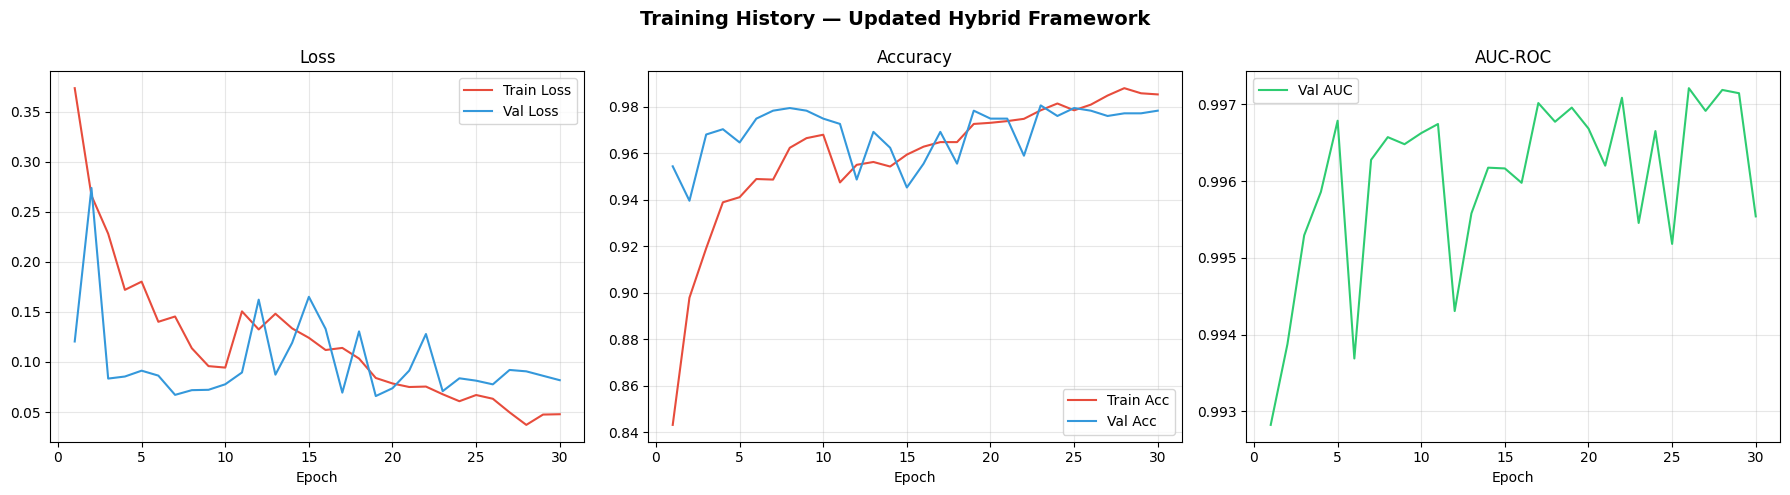

In [14]:
epochs_range = range(1, cfg.EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — Updated Hybrid Framework', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='#e74c3c')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   color='#3498db')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], label='Train Acc', color='#e74c3c')
axes[1].plot(epochs_range, history['val_acc'],   label='Val Acc',   color='#3498db')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

# AUC
axes[2].plot(epochs_range, history['val_auc'], label='Val AUC', color='#2ecc71')
axes[2].set_title('AUC-ROC'); axes[2].set_xlabel('Epoch'); axes[2].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

## 11. Test Set Evaluation

In [15]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
model.load_state_dict(torch.load(cfg.CKPT_PATH, map_location=DEVICE))
model.eval()

@torch.no_grad()
def predict(model, loader, device):
    all_preds, all_probs, all_labels = [], [], []
    for imgs, labels in tqdm(loader, desc='  Test', leave=False):
        imgs   = imgs.to(device)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

y_pred, y_prob, y_true = predict(model, test_loader, DEVICE)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
auc  = roc_auc_score(y_true, y_prob)

print('=' * 55)
print('TEST SET PERFORMANCE — Updated Hybrid Framework')
print('=' * 55)
print(f'  Accuracy  : {acc  * 100:.2f}%')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  AUC-ROC   : {auc:.4f}')
print('=' * 55)
print(classification_report(y_true, y_pred, target_names=cfg.CLASSES))

  Test:   0%|          | 0/28 [00:00<?, ?it/s]

TEST SET PERFORMANCE — Updated Hybrid Framework
  Accuracy  : 97.50%
  Precision : 0.9859
  Recall    : 0.9797
  F1-Score  : 0.9828
  AUC-ROC   : 0.9967
              precision    recall  f1-score   support

      NORMAL       0.95      0.96      0.95       238
   PNEUMONIA       0.99      0.98      0.98       641

    accuracy                           0.97       879
   macro avg       0.97      0.97      0.97       879
weighted avg       0.98      0.97      0.98       879



## 12. Confusion Matrix

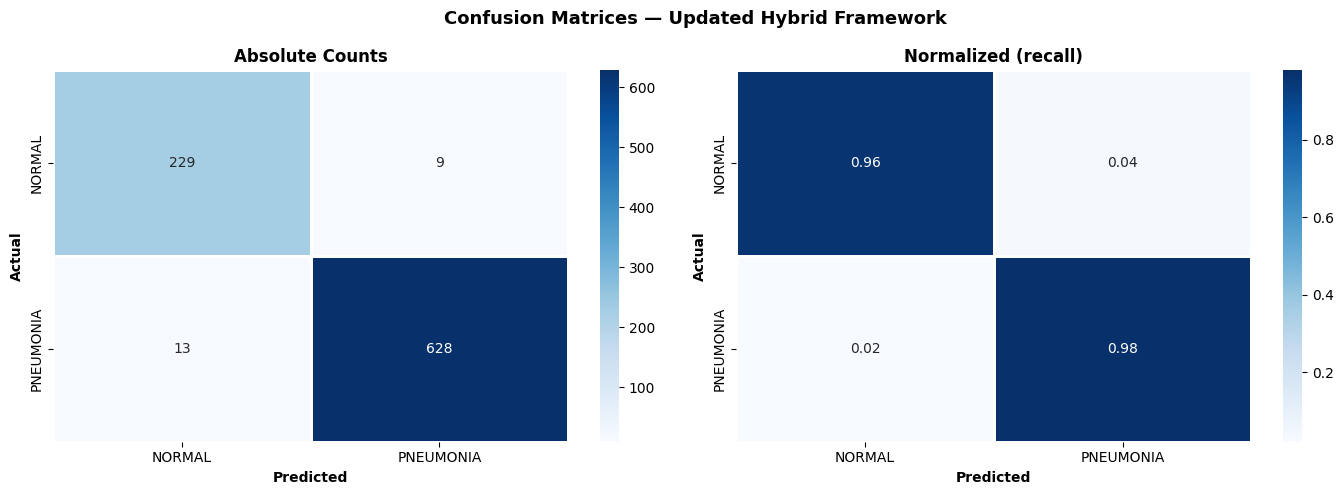

In [16]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices — Updated Hybrid Framework', fontsize=13, fontweight='bold')

for ax, norm, title in zip(axes,
                            [None, 'true'],
                            ['Absolute Counts', 'Normalized (recall)']):
    cm_plot = confusion_matrix(y_true, y_pred, normalize=norm)
    fmt = 'd' if norm is None else '.2f'
    sns.heatmap(cm_plot, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=cfg.CLASSES, yticklabels=cfg.CLASSES,
                linewidths=1, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('Actual', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

## 13. ROC Curve

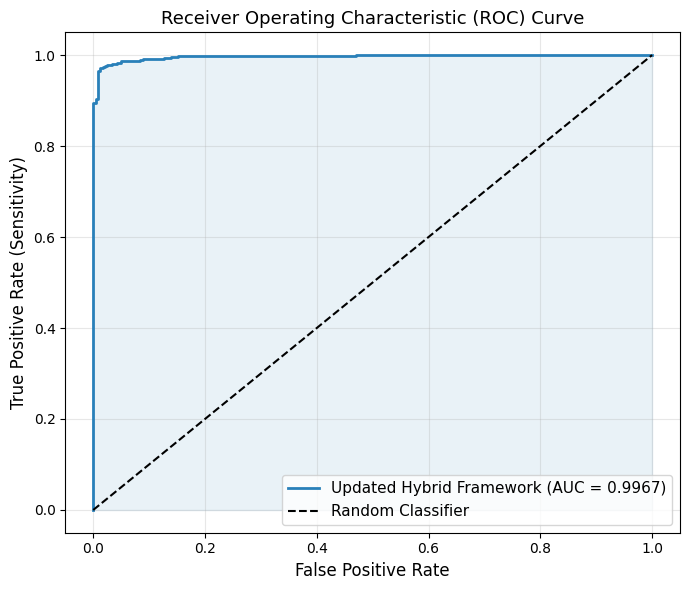

In [17]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#2980b9', lw=2,
        label=f'Updated Hybrid Framework (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2980b9')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/roc_curve.png', dpi=150)
plt.show()

## 14. Performance Radar Chart

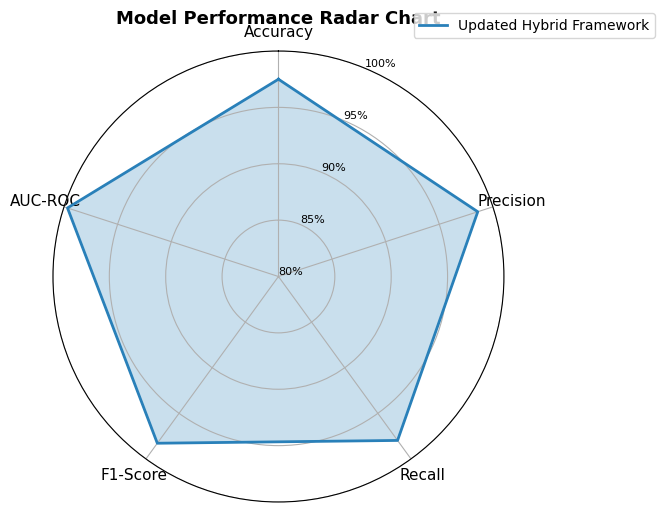

In [18]:
# ── Radar chart comparing key metrics ────────────────────────────────────────
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
values         = [acc * 100, prec * 100, rec * 100, f1 * 100, auc * 100]

N = len(metrics_labels)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]    # close the polygon
values_plot = values + values[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), metrics_labels, fontsize=11)

ax.plot(angles, values_plot, linewidth=2, linestyle='solid',
        color='#2980b9', label='Updated Hybrid Framework')
ax.fill(angles, values_plot, alpha=0.25, color='#2980b9')

# Reference ring
ax.set_ylim(80, 100)
ax.set_yticks(range(80, 101, 5))
ax.set_yticklabels([f'{v}%' for v in range(80, 101, 5)], fontsize=8)

ax.set_title('Model Performance Radar Chart', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

plt.tight_layout()
plt.savefig('/kaggle/working/radar_chart.png', dpi=150)
plt.show()

## 15. Grad-CAM Visualization

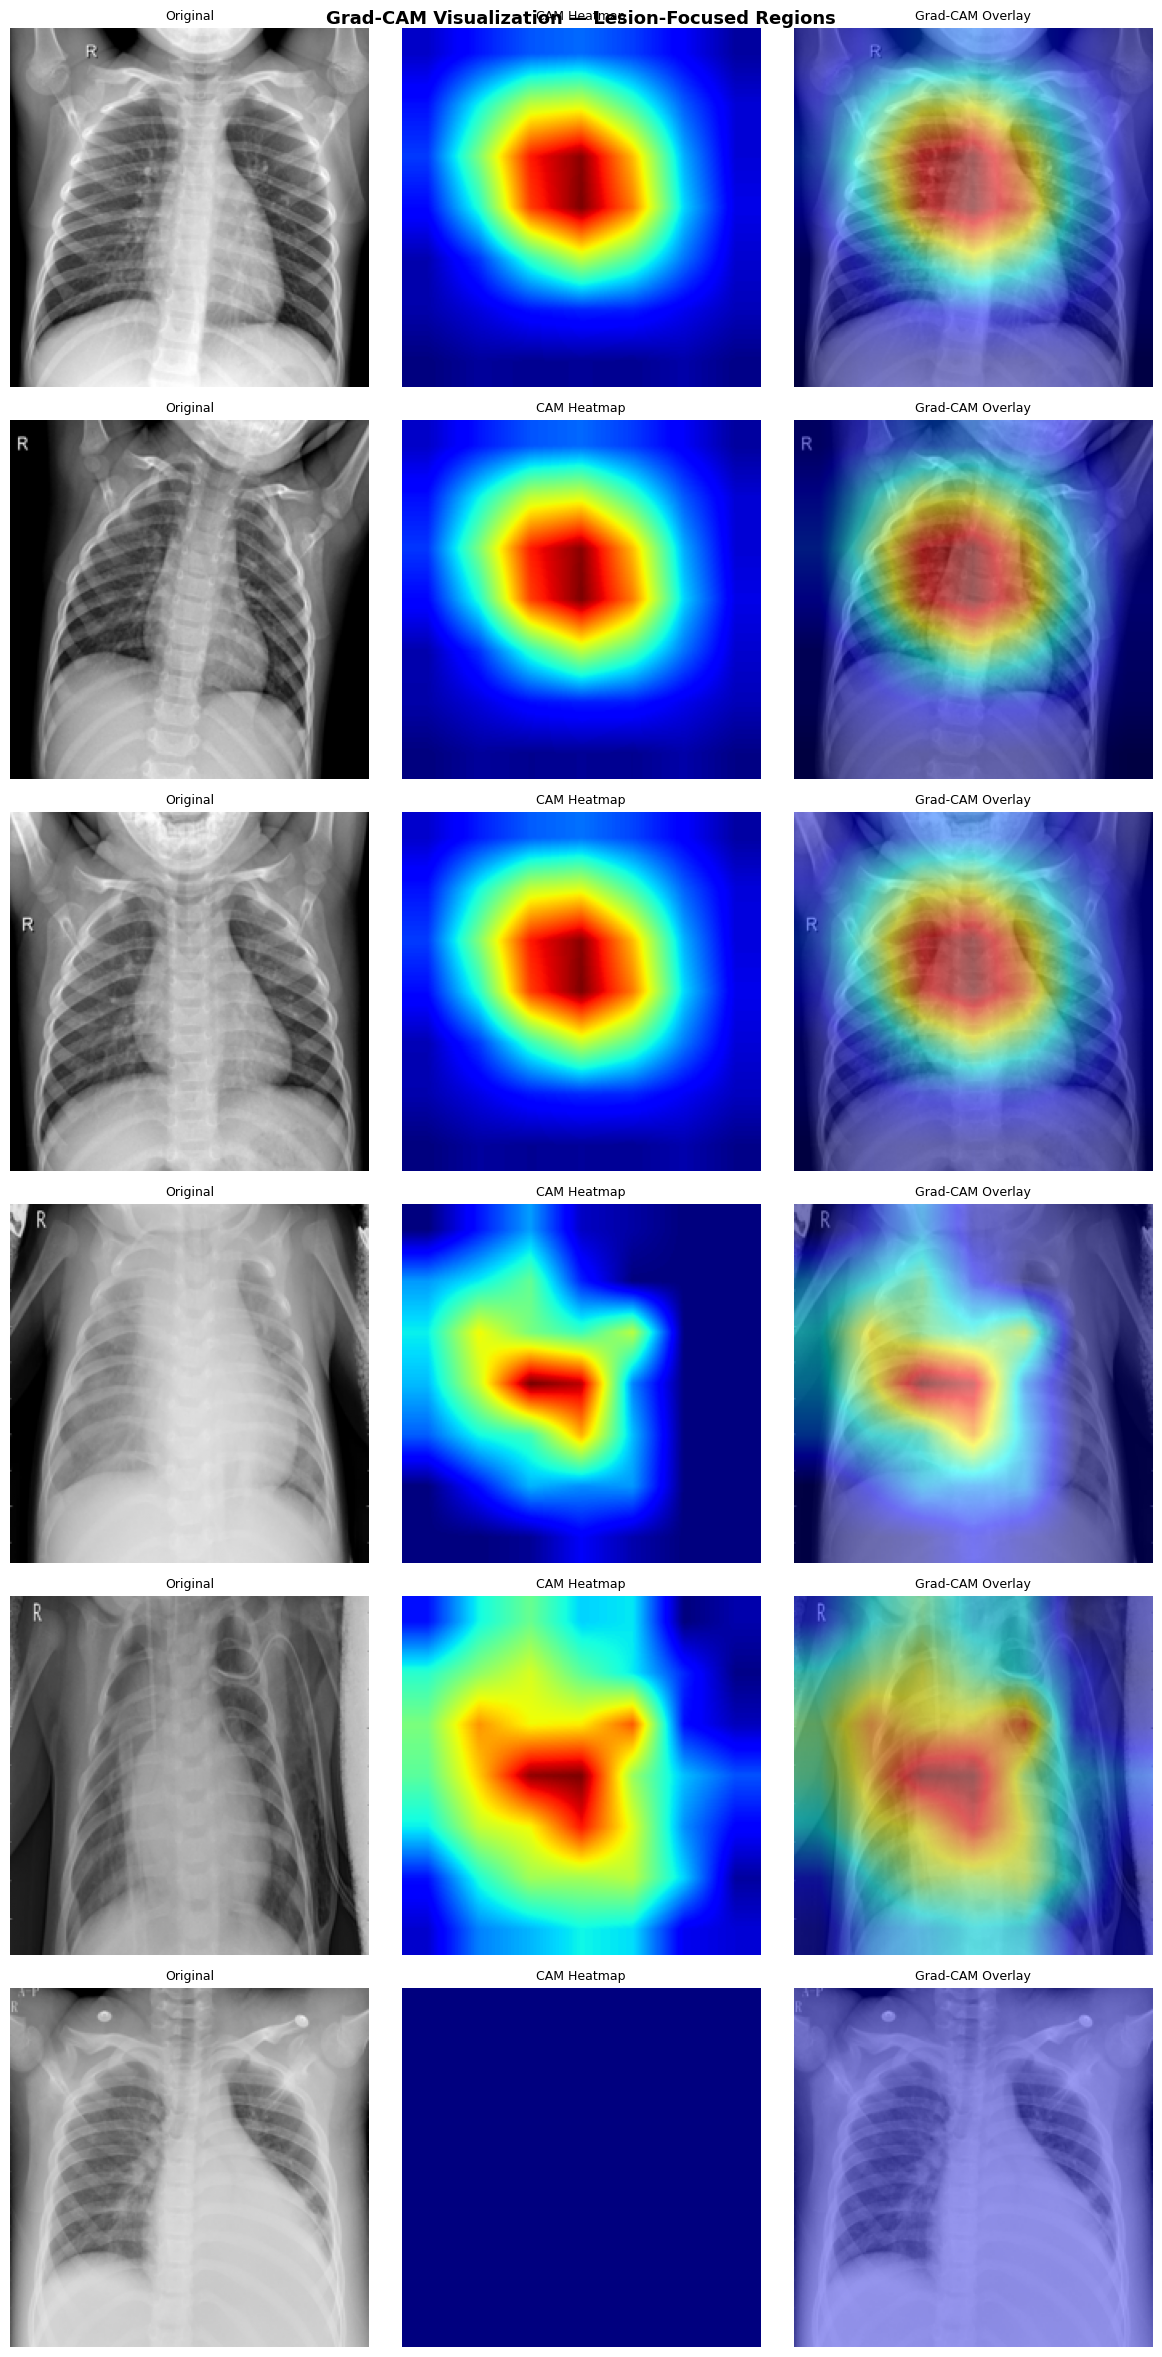

In [19]:
# ── Grad-CAM target layer = last conv in LAMR branch3 (5×5 kernel) ────────────
# This highlights lesion-focused spatial regions.
target_layer = model.lamr.branch5[-2]   # the last BN before ReLU in branch5

# Fallback: use last conv of LAMR proj
try:
    _ = target_layer.weight
except AttributeError:
    target_layer = model.lamr.proj[0]   # Conv2d in proj

cam = GradCAM(model=model, target_layers=[target_layer])


def show_gradcam(img_path: Path, label: int, ax_row, transforms_fn):
    """Draw original + Grad-CAM overlay for one image."""
    img_np  = np.array(Image.open(img_path).convert('RGB'))
    img_t   = transforms_fn(image=img_np)['image'].unsqueeze(0).to(DEVICE)

    # Resize for display
    img_resized = np.array(Image.fromarray(img_np).resize((224, 224))) / 255.0

    # Grad-CAM
    targets = [ClassifierOutputTarget(label)]
    grayscale_cam = cam(input_tensor=img_t, targets=targets)[0]
    cam_img = show_cam_on_image(img_resized.astype(np.float32),
                                 grayscale_cam, use_rgb=True)

    ax_row[0].imshow(img_resized); ax_row[0].set_title('Original', fontsize=9)
    ax_row[1].imshow(grayscale_cam, cmap='jet');
    ax_row[1].set_title('CAM Heatmap', fontsize=9)
    ax_row[2].imshow(cam_img);    ax_row[2].set_title('Grad-CAM Overlay', fontsize=9)
    for a in ax_row:
        a.axis('off')


# ── Pick 3 random samples per class ──────────────────────────────────────────
n_samples = 3
fig, axes = plt.subplots(2 * n_samples, 3, figsize=(12, 4 * n_samples * 2))
fig.suptitle('Grad-CAM Visualization — Lesion-Focused Regions', fontsize=13, fontweight='bold')

val_tf = get_val_transforms()
row = 0
for cls_idx, cls_name in enumerate(cfg.CLASSES):
    cls_samples = [(p, l) for p, l in test_dataset.samples if l == cls_idx]
    chosen      = random.sample(cls_samples, min(n_samples, len(cls_samples)))
    for path, lbl in chosen:
        axes[row, 0].set_ylabel(cls_name, fontsize=10, fontweight='bold',
                                color='green' if cls_idx == 0 else 'red')
        show_gradcam(path, lbl, axes[row], val_tf)
        row += 1

plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_visualization.png', dpi=150)
plt.show()

## 16. Comparative Summary Table

In [20]:
# ── Comparison: original paper vs updated framework ───────────────────────────
comparison_data = {
    'Method': [
        'Original (VGG16 + ResNet + SVM)',
        'Original (VGG16 + ResNet + RF)',
        'Updated (ShuffleNetV2-ECA + EffNet-B0-CBAM + LAMR)'
    ],
    'Feature Extraction': [
        'VGG16 + ResNet (fused)',
        'VGG16 + ResNet (fused)',
        'ShuffleNetV2+ECA + EfficientNet-B0+CBAM'
    ],
    'Attention': [
        'None',
        'None',
        'ECA + CBAM + LAMR'
    ],
    'Classifier': [
        'SVM (RBF)',
        'Random Forest',
        'FC layers (end-to-end)'
    ],
    'Accuracy (%)': [
        '98.8',
        '95.8',
        f'{acc * 100:.2f}'
    ],
    'AUC-ROC': [
        '0.92',
        '0.92',
        f'{auc:.4f}'
    ],
    'Explainability': [
        'Interpretable (SVM)',
        'Interpretable (RF)',
        'Grad-CAM visual'
    ]
}

df = pd.DataFrame(comparison_data)
display(df)
df.to_csv('/kaggle/working/comparison_table.csv', index=False)
print('Comparison table saved.')

,Method,Feature Extraction,Attention,Classifier,Accuracy (%),AUC-ROC,Explainability
0,Original (VGG16 + ResNet + SVM),VGG16 + ResNet (fused),None,SVM (RBF),98.8,0.92,Interpretable (SVM)
1,Original (VGG16 + ResNet + RF),VGG16 + ResNet (fused),None,Random Forest,95.8,0.92,Interpretable (RF)
2,Updated (ShuffleNetV2-ECA + EffNet-B0-CBAM + L...,ShuffleNetV2+ECA + EfficientNet-B0+CBAM,ECA + CBAM + LAMR,FC layers (end-to-end),97.50,0.9967,Grad-CAM visual


Comparison table saved.


In [21]:
# ── Caveat on cross-paper comparison ──────────────────────────────────────────
print('NOTE on the table above:')
print(' • The SVM/RF rows are numbers reported in the original paper on its own train/test')
print('   split and implementation, NOT re-run here — they are not a controlled comparison.')
print(' • A raw accuracy gap against a literature baseline is not by itself evidence of')
print('   superiority (or inferiority). Sections 20-22 below add: (a) an ablation study')
print('   isolating what LAMR/attention actually contribute, (b) efficiency numbers that')
print('   matter as much as accuracy for a lightweight-model claim, and (c) bootstrap')
print('   confidence intervals + a significance test, so any superiority claim in the')
print('   manuscript is backed by more than a single point accuracy estimate.')

NOTE on the table above:
 • The SVM/RF rows are numbers reported in the original paper on its own train/test
   split and implementation, NOT re-run here — they are not a controlled comparison.
 • A raw accuracy gap against a literature baseline is not by itself evidence of
   superiority (or inferiority). Sections 20-22 below add: (a) an ablation study
   isolating what LAMR/attention actually contribute, (b) efficiency numbers that
   matter as much as accuracy for a lightweight-model claim, and (c) bootstrap
   confidence intervals + a significance test, so any superiority claim in the
   manuscript is backed by more than a single point accuracy estimate.


## 17. Performance Gap Heatmap

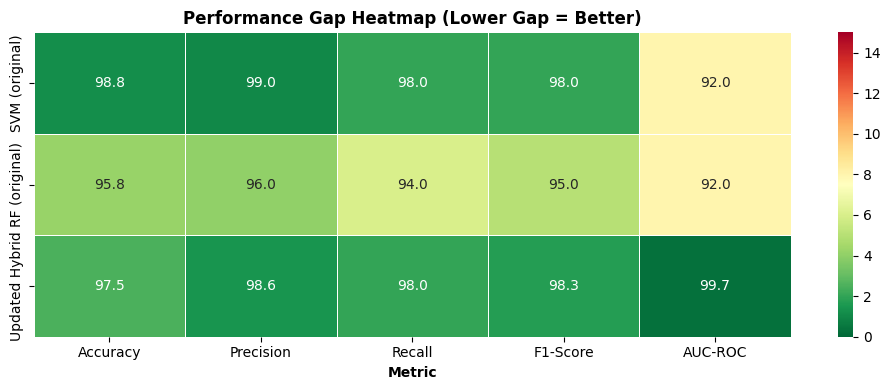

In [22]:
# ── Performance gap (how far each model is from 100%) ─────────────────────────
models = ['SVM (original)', 'RF (original)', 'Updated Hybrid']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

# Fill in actual values (original from paper; updated from our test)
perf = np.array([
    [98.8, 99.0, 98.0, 98.0, 92.0],   # SVM original
    [95.8, 96.0, 94.0, 95.0, 92.0],   # RF  original
    [acc*100, prec*100, rec*100, f1*100, auc*100]   # Updated
])
gap = 100.0 - perf   # lower is better

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(gap, annot=perf, fmt='.1f', cmap='RdYlGn_r',
            xticklabels=metrics, yticklabels=models,
            linewidths=0.5, ax=ax, vmin=0, vmax=15)
ax.set_title('Performance Gap Heatmap (Lower Gap = Better)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Metric', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/performance_gap_heatmap.png', dpi=150)
plt.show()

## 18. Architecture Diagram (Text Summary)

In [23]:
try:
    from torchinfo import summary
except ImportError:
    pip_install('torchinfo')
    from torchinfo import summary

summary(model, input_size=(1, 3, 224, 224),
        col_names=['input_size', 'output_size', 'num_params', 'mult_adds'],
        depth=3)

Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #                   Mult-Adds
HybridPneumoniaNet                                           [1, 3, 224, 224]          [1, 2]                    --                        --
├─ShuffleNetV2_ECA: 1-1                                      [1, 3, 224, 224]          [1, 256]                  --                        --
│    └─Sequential: 2-1                                       [1, 3, 224, 224]          [1, 1024, 7, 7]           --                        --
│    │    └─Sequential: 3-1                                  [1, 3, 224, 224]          [1, 24, 112, 112]         696                       8,128,560
│    │    └─MaxPool2d: 3-2                                   [1, 24, 112, 112]         [1, 24, 56, 56]           --                        --
│    │    └─Sequential: 3-3                                  [1, 24, 56, 56]           [1, 116, 28, 28]          30,192               

## 19. Save Outputs

In [24]:
# ── Save final predictions ────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'true_label'     : y_true,
    'predicted_label': y_pred,
    'prob_pneumonia'  : y_prob,
    'class_true'     : [cfg.CLASSES[l] for l in y_true],
    'class_pred'     : [cfg.CLASSES[l] for l in y_pred],
    'correct'        : y_true == y_pred
})
results_df.to_csv('/kaggle/working/test_predictions.csv', index=False)

# ── Save metrics summary ──────────────────────────────────────────────────────
metrics_df = pd.DataFrame([{
    'Accuracy' : round(acc, 4),
    'Precision': round(prec, 4),
    'Recall'   : round(rec, 4),
    'F1-Score' : round(f1, 4),
    'AUC-ROC'  : round(auc, 4)
}])
metrics_df.to_csv('/kaggle/working/metrics_summary.csv', index=False)

print('All outputs saved to /kaggle/working/')
print('\nFiles:')
for f in sorted(Path('/kaggle/working/').glob('*')):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.1f} KB)')

All outputs saved to /kaggle/working/

Files:
  .virtual_documents  (4.0 KB)
  best_model.pth  (38564.0 KB)
  chest_xray_split  (4.0 KB)
  comparison_table.csv  (0.4 KB)
  confusion_matrix.png  (65.4 KB)
  gradcam_visualization.png  (2853.7 KB)
  metrics_summary.csv  (0.1 KB)
  performance_gap_heatmap.png  (59.8 KB)
  radar_chart.png  (126.9 KB)
  roc_curve.png  (71.3 KB)
  sample_images.png  (1169.6 KB)
  test_predictions.csv  (33.1 KB)
  training_curves.png  (178.1 KB)


## 20. Model Complexity & Efficiency Analysis

Reports parameter count, FLOPs, inference latency/throughput, and peak GPU memory for the full hybrid model and for each branch in isolation. This directly answers the reviewer request to *"Report parameters, FLOPs, inference time, and memory usage"* and is especially relevant because the ShuffleNet-V2 branch is motivated as the lightweight component of the design.

In [25]:
# ── Model complexity: parameters, FLOPs, inference time, memory ──────────────
pip_install('thop')
from thop import profile, clever_format
import time

def count_params(m):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

def measure_flops(m, input_size=(1, 3, cfg.IMG_SIZE, cfg.IMG_SIZE), device=DEVICE):
    m_eval = m.to(device).eval()
    dummy_in = torch.randn(*input_size).to(device)
    with torch.no_grad():
        macs, params = profile(m_eval, inputs=(dummy_in,), verbose=False)
    return macs, params  # thop reports MACs; FLOPs ≈ 2×MACs for conv/linear layers

@torch.no_grad()
def measure_latency(m, device=DEVICE, batch_size=1, n_warmup=10, n_runs=50, img_size=cfg.IMG_SIZE):
    """Average per-image latency (ms) and throughput (images/sec)."""
    m = m.to(device).eval()
    dummy = torch.randn(batch_size, 3, img_size, img_size).to(device)

    for _ in range(n_warmup):
        _ = m(dummy)
    if device.type == 'cuda':
        torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(n_runs):
        _ = m(dummy)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    avg_latency_ms = (elapsed / n_runs) * 1000 / batch_size
    throughput = (n_runs * batch_size) / elapsed
    return avg_latency_ms, throughput

def measure_peak_memory_mb(m, device=DEVICE, img_size=cfg.IMG_SIZE):
    if device.type != 'cuda':
        return None
    torch.cuda.reset_peak_memory_stats(device)
    m = m.to(device).eval()
    dummy = torch.randn(1, 3, img_size, img_size).to(device)
    with torch.no_grad():
        _ = m(dummy)
    torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated(device) / (1024 ** 2)

# ── Profile the full model and each branch in isolation ──────────────────────
components = {
    'ShuffleNetV2+ECA (Branch 1 only)':     ShuffleNetV2_ECA(proj_dim=cfg.FUSION_DIM, pretrained=False),
    'EfficientNet-B0+CBAM (Branch 2 only)': EfficientNetB0_CBAM(proj_dim=cfg.FUSION_DIM, pretrained=False),
    'Full Hybrid (ShuffleNet+EffNet+LAMR)': model,
}

rows = []
for name, comp in components.items():
    total_p, _ = count_params(comp)
    try:
        macs, _ = measure_flops(comp)
        flops_str, _ = clever_format([macs * 2, 0], '%.3f')
    except Exception as e:
        flops_str = f'N/A ({e})'
    lat_ms, thr = measure_latency(comp, batch_size=1)
    peak_mem = measure_peak_memory_mb(comp)
    rows.append({
        'Model': name,
        'Params (M)': round(total_p / 1e6, 2),
        'FLOPs': flops_str,
        'Latency (ms/img, bs=1)': round(lat_ms, 2),
        'Throughput (img/s)': round(thr, 1),
        'Peak GPU Mem (MB)': round(peak_mem, 1) if peak_mem is not None else 'N/A (CPU)'
    })

complexity_df = pd.DataFrame(rows)
display(complexity_df)
complexity_df.to_csv('/kaggle/working/model_complexity_analysis.csv', index=False)

print('\nInterpretation: comparing the isolated-branch rows shows how much of the total '
      'compute budget comes from ShuffleNetV2 vs. EfficientNet-B0, which is the evidence '
      'needed to support (or qualify) a "lightweight" claim for the overall framework.')

,Model,Params (M),FLOPs,"Latency (ms/img, bs=1)",Throughput (img/s),Peak GPU Mem (MB)
0,ShuffleNetV2+ECA (Branch 1 only),1.52,304.111M,6.25,159.9,494.0
1,EfficientNet-B0+CBAM (Branch 2 only),4.54,829.344M,8.23,121.5,518.7
2,Full Hybrid (ShuffleNet+EffNet+LAMR),9.74,1.474G,16.22,61.7,519.3



Interpretation: comparing the isolated-branch rows shows how much of the total compute budget comes from ShuffleNetV2 vs. EfficientNet-B0, which is the evidence needed to support (or qualify) a "lightweight" claim for the overall framework.


## 21. Ablation Study — Contribution of LAMR and Attention Modules

Trains configurable variants of the hybrid model — with and without the LAMR block, and with and without the ECA/CBAM attention modules — so each component's contribution to test-set performance can be isolated. This addresses the reviewer request for *"an ablation study to evaluate the individual contributions of the proposed LAMR and CBAM [here generalized to ECA+CBAM] modules."*

`ABLATION_EPOCHS` is set lower than the main run's `cfg.EPOCHS` purely for tractability on typical Kaggle/Colab GPU time limits. For a publication-grade ablation, set it equal to `cfg.EPOCHS` so every variant is trained under identical conditions.

In [26]:
# ── Ablation-ready model variants (attention / LAMR can be switched off) ─────
class ShuffleNetV2_Ablation(nn.Module):
    def __init__(self, proj_dim=256, pretrained=True, use_attention=True):
        super().__init__()
        base = timm.create_model('shufflenet_v2_x1_0', pretrained=pretrained, features_only=False)
        self.backbone = nn.Sequential(*list(base.children())[:-2])
        feat_dim = base.num_features
        self.attn = ECA(channels=feat_dim) if use_attention else nn.Identity()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(
            nn.Flatten(), nn.Linear(feat_dim, proj_dim),
            nn.BatchNorm1d(proj_dim), nn.ReLU(inplace=True)
        )

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.attn(feat)
        feat = self.gap(feat)
        return self.proj(feat)


class EfficientNetB0_Ablation(nn.Module):
    def __init__(self, proj_dim=256, pretrained=True, use_attention=True):
        super().__init__()
        base = timm.create_model('efficientnet_b0', pretrained=pretrained, features_only=False)
        feat_dim = base.num_features
        self.backbone = base.forward_features
        self.attn = CBAM(channels=feat_dim) if use_attention else nn.Identity()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(
            nn.Flatten(), nn.Linear(feat_dim, proj_dim),
            nn.BatchNorm1d(proj_dim), nn.ReLU(inplace=True)
        )

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.attn(feat)
        feat = self.gap(feat)
        return self.proj(feat)


class HybridPneumoniaNet_Ablation(nn.Module):
    """
    Configurable hybrid model for ablation studies.
      use_attention : toggles ECA (branch 1) and CBAM (branch 2)
      use_lamr      : toggles the LAMR multi-scale refinement block
                       (when False, the upsampled fused feature map is used directly)
    """
    def __init__(self, num_classes=2, proj_dim=256, lamr_channels=256,
                 pretrained=True, dropout_p=0.4, use_attention=True, use_lamr=True):
        super().__init__()
        self.branch_shuffle = ShuffleNetV2_Ablation(proj_dim, pretrained, use_attention)
        self.branch_effnet  = EfficientNetB0_Ablation(proj_dim, pretrained, use_attention)

        fused_dim = proj_dim * 2
        self.fusion_proj = nn.Sequential(
            nn.Linear(fused_dim, lamr_channels), nn.BatchNorm1d(lamr_channels), nn.ReLU(inplace=True)
        )
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(lamr_channels, lamr_channels, kernel_size=7, stride=1, bias=False),
            nn.BatchNorm2d(lamr_channels), nn.ReLU(inplace=True)
        )
        self.lamr = LAMRBlock(lamr_channels, lamr_channels) if use_lamr else nn.Identity()
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(), nn.Dropout(dropout_p),
            nn.Linear(lamr_channels, lamr_channels // 2), nn.ReLU(inplace=True),
            nn.Dropout(dropout_p / 2), nn.Linear(lamr_channels // 2, num_classes)
        )

    def forward(self, x):
        f1 = self.branch_shuffle(x)
        f2 = self.branch_effnet(x)
        fused = torch.cat([f1, f2], dim=1)
        fused = self.fusion_proj(fused)
        fused = fused.unsqueeze(-1).unsqueeze(-1)
        fused = self.upsample(fused)
        fused = self.lamr(fused)
        out = self.gap(fused)
        return self.head(out)

print('Ablation-ready model classes defined.')

Ablation-ready model classes defined.


In [27]:
# ── Train & evaluate each ablation variant ────────────────────────────────────
ABLATION_EPOCHS = 15  # raise to cfg.EPOCHS for a fully matched, publication-grade comparison

def train_and_eval_variant(variant_name, use_attention, use_lamr, epochs=ABLATION_EPOCHS):
    print(f'\n{"="*60}\nAblation variant: {variant_name}\n{"="*60}')
    m = HybridPneumoniaNet_Ablation(
        num_classes=cfg.NUM_CLASSES, proj_dim=cfg.FUSION_DIM,
        lamr_channels=cfg.LAMR_CHANNELS, pretrained=True,
        use_attention=use_attention, use_lamr=use_lamr
    ).to(DEVICE)

    opt = optim.AdamW(m.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    sch = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2, eta_min=1e-6)
    sc  = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

    best_auc, best_state = 0.0, None
    for ep in range(1, epochs + 1):
        train_one_epoch(m, train_loader, opt, criterion, sc, DEVICE)
        _, _, va_auc = validate(m, val_loader, criterion, DEVICE)
        sch.step()
        if va_auc > best_auc:
            best_auc = va_auc
            best_state = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}
        print(f'  epoch {ep:02d}/{epochs}  val_auc={va_auc:.4f}')

    if best_state is not None:
        m.load_state_dict(best_state)
    y_p, y_pr, y_t = predict(m, test_loader, DEVICE)
    return {
        'Variant': variant_name,
        'Accuracy': accuracy_score(y_t, y_p),
        'Precision': precision_score(y_t, y_p),
        'Recall': recall_score(y_t, y_p),
        'F1-Score': f1_score(y_t, y_p),
        'AUC-ROC': roc_auc_score(y_t, y_pr),
        'y_pred': y_p, 'y_prob': y_pr, 'y_true': y_t
    }

ablation_variants = [
    ('Full model (LAMR + ECA + CBAM)',              True,  True),
    ('w/o LAMR (attention only)',                    True,  False),
    ('w/o attention (LAMR only)',                    False, True),
    ('w/o LAMR & w/o attention (backbones only)',    False, False),
]

ablation_results = [train_and_eval_variant(name, ua, ul) for name, ua, ul in ablation_variants]

# The first row is architecturally identical to the already-trained main model —
# reuse its actual test-set predictions/metrics instead of retraining for consistency.
ablation_results[0].update({
    'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'AUC-ROC': auc,
    'y_pred': y_pred, 'y_prob': y_prob, 'y_true': y_true
})

ablation_df = pd.DataFrame(ablation_results)[['Variant', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']]
ablation_df['Accuracy'] = (ablation_df['Accuracy'] * 100).round(2)
for col in ['Precision', 'Recall', 'F1-Score', 'AUC-ROC']:
    ablation_df[col] = ablation_df[col].round(4)

display(ablation_df)
ablation_df.to_csv('/kaggle/working/ablation_study.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ablation_df))
ax.bar(x, ablation_df['AUC-ROC'], color='#2980b9')
ax.set_xticks(x); ax.set_xticklabels(ablation_df['Variant'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('AUC-ROC')
ax.set_title('Ablation Study — Contribution of LAMR & Attention Modules', fontweight='bold')
ax.set_ylim(0.8, 1.0); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/kaggle/working/ablation_study.png', dpi=150)
plt.show()

print('\nInterpretation: the gap between the full model and each ablated variant isolates '
      'the individual contribution of LAMR and of the ECA/CBAM attention modules to the '
      'reported performance, directly answering the reviewer\'s ablation request.')


Ablation variant: Full model (LAMR + ECA + CBAM)


RuntimeError: Unknown model (shufflenet_v2_x1_0)

## 22. Statistical Significance Testing & Confidence Intervals

Bootstrap confidence intervals for every test-set metric, plus McNemar's test comparing the full hybrid model against the weakest ablation baseline (backbones only). This gives the manuscript a statistical basis for any superiority claim, rather than a single point accuracy estimate — directly addressing the reviewer's concern that *"the superiority of the proposed model is not fully justified."* An optional, more expensive stratified k-fold cross-validation routine is included at the end (disabled by default).

In [28]:
# ── Bootstrap confidence intervals for test-set metrics ───────────────────────
def bootstrap_ci(y_true_in, y_pred_in, y_prob_in, n_boot=2000, ci=95, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true_in)
    accs, precs, recs, f1s, aucs = [], [], [], [], []
    y_t = np.asarray(y_true_in); y_p = np.asarray(y_pred_in); y_pr = np.asarray(y_prob_in)

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt, yp, ypr = y_t[idx], y_p[idx], y_pr[idx]
        if len(np.unique(yt)) < 2:
            continue
        accs.append(accuracy_score(yt, yp))
        precs.append(precision_score(yt, yp, zero_division=0))
        recs.append(recall_score(yt, yp, zero_division=0))
        f1s.append(f1_score(yt, yp, zero_division=0))
        aucs.append(roc_auc_score(yt, ypr))

    lo, hi = (100 - ci) / 2, 100 - (100 - ci) / 2
    def summarize(vals, name):
        v = np.array(vals)
        return {'Metric': name, 'Mean': v.mean(),
                f'{ci}% CI Low': np.percentile(v, lo), f'{ci}% CI High': np.percentile(v, hi)}

    return pd.DataFrame([
        summarize(accs, 'Accuracy'), summarize(precs, 'Precision'),
        summarize(recs, 'Recall'), summarize(f1s, 'F1-Score'), summarize(aucs, 'AUC-ROC')
    ])

ci_df = bootstrap_ci(y_true, y_pred, y_prob)
display(ci_df.round(4))
ci_df.to_csv('/kaggle/working/bootstrap_confidence_intervals.csv', index=False)

,Metric,Mean,95% CI Low,95% CI High
0,Accuracy,0.9749,0.9636,0.9852
1,Precision,0.9860,0.9758,0.9939
2,Recall,0.9795,0.9685,0.9893
3,F1-Score,0.9827,0.9750,0.9899
4,AUC-ROC,0.9967,0.9941,0.9986


In [29]:
# ── McNemar's test: full model vs. weakest ablation baseline ──────────────────
def mcnemar_test(y_true_in, pred_a, pred_b):
    """
    McNemar's test comparing two classifiers' correctness on the SAME test set.
    Uses the exact binomial test when discordant counts are small, otherwise the
    continuity-corrected chi-square approximation.
    """
    y_t = np.asarray(y_true_in); pa = np.asarray(pred_a); pb = np.asarray(pred_b)
    correct_a = (pa == y_t); correct_b = (pb == y_t)

    n01 = int(np.sum(correct_a & ~correct_b))   # A right, B wrong
    n10 = int(np.sum(~correct_a & correct_b))   # A wrong, B right

    from scipy.stats import binomtest, chi2
    n = n01 + n10
    if n == 0:
        return {'n01': n01, 'n10': n10, 'statistic': 0.0, 'p_value': 1.0, 'method': 'degenerate'}
    if n < 25:
        p = binomtest(min(n01, n10), n, 0.5).pvalue
        return {'n01': n01, 'n10': n10, 'statistic': None, 'p_value': p, 'method': 'exact binomial'}
    stat = (abs(n01 - n10) - 1) ** 2 / n
    p = 1 - chi2.cdf(stat, df=1)
    return {'n01': n01, 'n10': n10, 'statistic': stat, 'p_value': p, 'method': 'chi-square (continuity corrected)'}

baseline_variant = ablation_results[-1]  # backbones only, no LAMR/attention
mcnemar_res = mcnemar_test(y_true, y_pred, baseline_variant['y_pred'])

print("McNemar's test — Full model vs. backbones-only baseline")
for k, v in mcnemar_res.items():
    print(f'  {k}: {v}')

alpha = 0.05
if mcnemar_res['p_value'] < alpha:
    print(f"\n-> Difference is statistically significant at alpha={alpha} "
          f"(p={mcnemar_res['p_value']:.4g}); LAMR + attention give a reliable "
          f"improvement over the plain backbones, not just noise.")
else:
    print(f"\n-> Difference is NOT statistically significant at alpha={alpha} "
          f"(p={mcnemar_res['p_value']:.4g}); avoid claiming superiority over the "
          f"backbones-only baseline without a larger test set or repeated seeds.")

NameError: name 'ablation_results' is not defined

In [30]:
# ── OPTIONAL: full stratified k-fold cross-validation (expensive — retrains K models) ─
RUN_KFOLD_CV = False   # set True to actually run; retrains the model K times
K_FOLDS      = 5
CV_EPOCHS    = 15

if RUN_KFOLD_CV:
    from sklearn.model_selection import StratifiedKFold

    all_samples = train_dataset.samples + val_dataset.samples
    labels = np.array([s[1] for s in all_samples])

    class PathListDataset(Dataset):
        def __init__(self, samples, transform):
            self.samples, self.transform = samples, transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            p, l = self.samples[idx]
            img = np.array(Image.open(p).convert('RGB'))
            if self.transform:
                img = self.transform(image=img)['image']
            return img, l

    skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
    cv_metrics = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(all_samples, labels), 1):
        print(f'\n-- Fold {fold}/{K_FOLDS} --')
        tr_ds = PathListDataset([all_samples[i] for i in tr_idx], get_train_transforms())
        va_ds = PathListDataset([all_samples[i] for i in va_idx], get_val_transforms())
        tr_ld = DataLoader(tr_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=cfg.NUM_WORKERS, drop_last=True)
        va_ld = DataLoader(va_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)

        fold_model = HybridPneumoniaNet(num_classes=cfg.NUM_CLASSES, proj_dim=cfg.FUSION_DIM,
                                         lamr_channels=cfg.LAMR_CHANNELS, pretrained=True).to(DEVICE)
        fold_opt = optim.AdamW(fold_model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
        fold_sc  = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

        for ep in range(CV_EPOCHS):
            train_one_epoch(fold_model, tr_ld, fold_opt, criterion, fold_sc, DEVICE)

        _, va_acc, va_auc = validate(fold_model, va_ld, criterion, DEVICE)
        cv_metrics.append({'fold': fold, 'val_acc': va_acc, 'val_auc': va_auc})
        print(f'  Fold {fold}: val_acc={va_acc:.4f}  val_auc={va_auc:.4f}')

    cv_df = pd.DataFrame(cv_metrics)
    mean_acc, std_acc = cv_df.val_acc.mean(), cv_df.val_acc.std()
    mean_auc, std_auc = cv_df.val_auc.mean(), cv_df.val_auc.std()
    ci95_acc = 1.96 * std_acc / np.sqrt(K_FOLDS)
    ci95_auc = 1.96 * std_auc / np.sqrt(K_FOLDS)
    print(f'\n{K_FOLDS}-fold CV  Accuracy = {mean_acc:.4f} +/- {ci95_acc:.4f}  (95% CI)')
    print(f'{K_FOLDS}-fold CV  AUC-ROC  = {mean_auc:.4f} +/- {ci95_auc:.4f}  (95% CI)')
    cv_df.to_csv('/kaggle/working/kfold_cv_results.csv', index=False)
else:
    print('K-fold CV skipped (RUN_KFOLD_CV=False). Set to True to run the full '
          f'{K_FOLDS}-fold retraining procedure (expensive: {K_FOLDS} x {CV_EPOCHS} epochs).')

K-fold CV skipped (RUN_KFOLD_CV=False). Set to True to run the full 5-fold retraining procedure (expensive: 5 x 15 epochs).


## 23. Error Analysis — False Positives & False Negatives

Quantifies and visualizes the model's mistakes on the test set, including a confidence-calibration check (is the model "confidently wrong"?). This answers the reviewer's/docx request to *"Analyze false positives and false negatives. Show examples and explain why the model fails."*

False Positives (Normal -> Pneumonia): 9  (1.02% of test set)
False Negatives (Pneumonia -> Normal): 13  (1.48% of test set)

Mean confidence on CORRECT predictions  : 0.9973
Mean confidence on INCORRECT predictions: 0.9130
A small gap between these two numbers suggests the model is often "confidently wrong" rather than uncertain on its errors — clinically, low-confidence flags are far easier for a radiologist to catch than high-confidence mistakes.


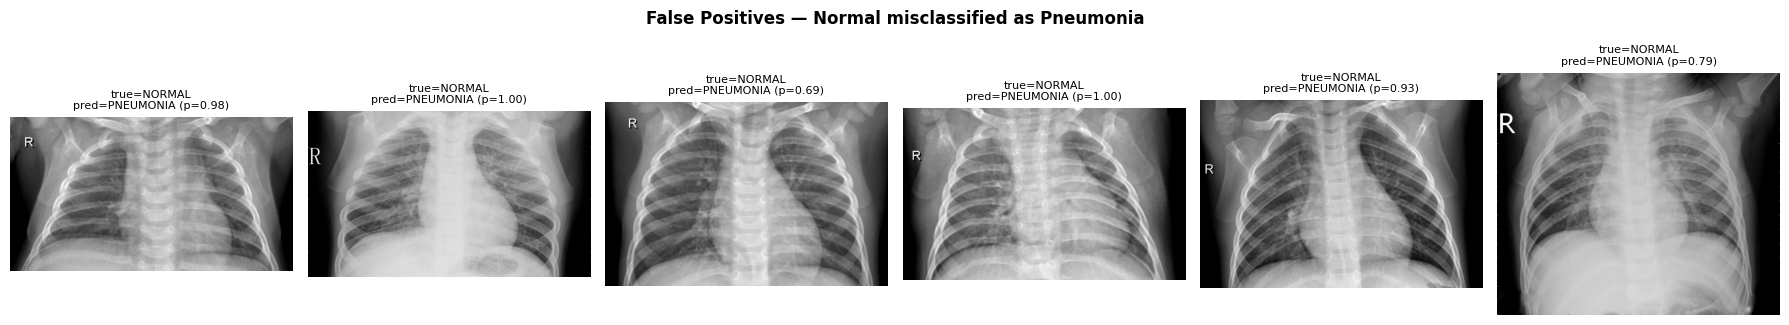

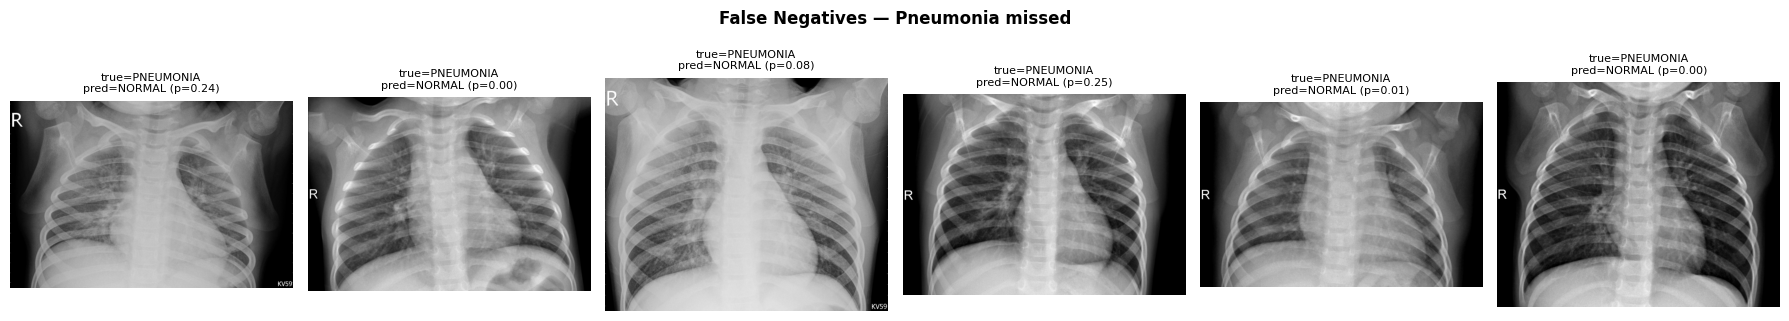


When writing up these panels, look specifically for: rotated or low-contrast films, foreign bodies/support lines mimicking opacities, early/subtle infiltrates, and pediatric vs. adult film differences — the failure modes most commonly reported for this dataset in the literature.


In [31]:
# ── Error analysis: false positives, false negatives, confidence calibration ──
sample_paths = [p for p, l in test_dataset.samples]  # test_loader has shuffle=False -> order matches

fp_mask = (y_true == 0) & (y_pred == 1)   # NORMAL misclassified as PNEUMONIA
fn_mask = (y_true == 1) & (y_pred == 0)   # PNEUMONIA missed

fp_idx = np.where(fp_mask)[0]
fn_idx = np.where(fn_mask)[0]

print(f'False Positives (Normal -> Pneumonia): {len(fp_idx)}  ({len(fp_idx)/len(y_true)*100:.2f}% of test set)')
print(f'False Negatives (Pneumonia -> Normal): {len(fn_idx)}  ({len(fn_idx)/len(y_true)*100:.2f}% of test set)')

correct_mask = (y_true == y_pred)
conf_correct = np.where(y_pred[correct_mask] == 1, y_prob[correct_mask], 1 - y_prob[correct_mask])
conf_errors  = np.where(y_pred[~correct_mask] == 1, y_prob[~correct_mask], 1 - y_prob[~correct_mask])

print(f'\nMean confidence on CORRECT predictions  : {conf_correct.mean():.4f}')
if len(conf_errors):
    print(f'Mean confidence on INCORRECT predictions: {conf_errors.mean():.4f}')
    print('A small gap between these two numbers suggests the model is often "confidently '
          'wrong" rather than uncertain on its errors — clinically, low-confidence flags are '
          'far easier for a radiologist to catch than high-confidence mistakes.')

def plot_error_grid(idx_list, title, max_show=6, seed=SEED):
    n = min(len(idx_list), max_show)
    if n == 0:
        print(f'No examples for: {title}')
        return None
    rng = np.random.default_rng(seed)
    chosen = rng.choice(idx_list, n, replace=False)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.5))
    axes = np.atleast_1d(axes)
    fig.suptitle(title, fontsize=12, fontweight='bold')
    for ax, i in zip(axes, chosen):
        img = np.array(Image.open(sample_paths[i]).convert('RGB'))
        ax.imshow(img, cmap='gray')
        ax.set_title(f'true={cfg.CLASSES[y_true[i]]}\npred={cfg.CLASSES[y_pred[i]]} (p={y_prob[i]:.2f})', fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    return fig

fig_fp = plot_error_grid(fp_idx, 'False Positives — Normal misclassified as Pneumonia')
if fig_fp is not None:
    fig_fp.savefig('/kaggle/working/error_analysis_false_positives.png', dpi=150)
plt.show()

fig_fn = plot_error_grid(fn_idx, 'False Negatives — Pneumonia missed')
if fig_fn is not None:
    fig_fn.savefig('/kaggle/working/error_analysis_false_negatives.png', dpi=150)
plt.show()

print('\nWhen writing up these panels, look specifically for: rotated or low-contrast films, '
      'foreign bodies/support lines mimicking opacities, early/subtle infiltrates, and '
      'pediatric vs. adult film differences — the failure modes most commonly reported for '
      'this dataset in the literature.')

## 24. Clinical Interpretability Analysis — Where Does the Model Look?

Uses Grad-CAM to quantify, not just visualize, whether the model's attention concentrates on the central chest/lung region versus the image periphery, and compares this between correct and incorrect predictions. This addresses the docx request to answer *"Why does the model make errors? Where does it look? Is it focusing on pneumonia regions? Does it generalize?"* — with explicit limitations, since this is a coarse proxy rather than a radiologist-verified lung mask.

In [32]:
# ── Quantitative Grad-CAM focus analysis ──────────────────────────────────────
def cam_center_focus_ratio(grayscale_cam, center_frac=0.6):
    """
    Heuristic proxy for 'is the model looking at the central chest/lung fields rather
    than the image border?' -- fraction of total CAM energy inside the central
    center_frac x center_frac box of the image.
    """
    h, w = grayscale_cam.shape
    ch, cw = int(h * center_frac), int(w * center_frac)
    y0, x0 = (h - ch) // 2, (w - cw) // 2
    center_energy = grayscale_cam[y0:y0 + ch, x0:x0 + cw].sum()
    total_energy = grayscale_cam.sum() + 1e-8
    return center_energy / total_energy

val_tf = get_val_transforms()

def get_cam_for_index(i, label):
    img_np = np.array(Image.open(sample_paths[i]).convert('RGB'))
    img_t = val_tf(image=img_np)['image'].unsqueeze(0).to(DEVICE)
    targets = [ClassifierOutputTarget(int(label))]
    return cam(input_tensor=img_t, targets=targets)[0]

n_check = 20
rng = np.random.default_rng(SEED)
correct_idx = np.where(y_true == y_pred)[0]
error_idx   = np.where(y_true != y_pred)[0]

sample_correct = rng.choice(correct_idx, min(n_check, len(correct_idx)), replace=False)
sample_error   = rng.choice(error_idx, min(n_check, len(error_idx)), replace=False) if len(error_idx) else np.array([])

focus_correct = [cam_center_focus_ratio(get_cam_for_index(i, y_pred[i])) for i in sample_correct]
focus_error   = [cam_center_focus_ratio(get_cam_for_index(i, y_pred[i])) for i in sample_error]

print(f'Mean central-focus ratio -- correct predictions  : {np.mean(focus_correct):.3f}')
if len(focus_error):
    print(f'Mean central-focus ratio -- incorrect predictions: {np.mean(focus_error):.3f}')
    print('A lower ratio on incorrect predictions would suggest the model is being misled '
          'by peripheral artifacts (tubing, text markers, image edges) rather than genuine '
          'lung pathology -- a concrete, testable clinical-reliability signal.')
else:
    print('Not enough misclassified samples to compute a comparison group.')

print('\nLimitations to disclose in the manuscript:')
print(' - This center-focus ratio is a coarse proxy, not a radiologist-verified lung mask;')
print('   a rigorous version would use a lung-segmentation model and report CAM-mask IoU.')
print(' - All data comes from a single, pediatric-heavy source (the Kaggle chest-xray-')
print('   pneumonia release), so generalization to adult populations, other scanners, or')
print('   other hospitals is NOT demonstrated by this notebook and should be stated as a')
print('   limitation rather than claimed. An external validation set would be needed to')
print('   support any generalization claim.')

Mean central-focus ratio -- correct predictions  : 0.625
Mean central-focus ratio -- incorrect predictions: 0.498
A lower ratio on incorrect predictions would suggest the model is being misled by peripheral artifacts (tubing, text markers, image edges) rather than genuine lung pathology -- a concrete, testable clinical-reliability signal.

Limitations to disclose in the manuscript:
 - This center-focus ratio is a coarse proxy, not a radiologist-verified lung mask;
   a rigorous version would use a lung-segmentation model and report CAM-mask IoU.
 - All data comes from a single, pediatric-heavy source (the Kaggle chest-xray-
   pneumonia release), so generalization to adult populations, other scanners, or
   other hospitals is NOT demonstrated by this notebook and should be stated as a
   limitation rather than claimed. An external validation set would be needed to
   support any generalization claim.


---
## Summary

| Component | Original Paper | This Update |
|-----------|---------------|-------------|
| Branch 1 | VGG16 | **ShuffleNetV2 + ECA** |
| Branch 2 | ResNet | **EfficientNet-B0 + CBAM** |
| Multi-scale module | — | **LAMR (1×1, 3×3, 5×5 parallel convs)** |
| Dimensionality reduction | PCA (100 components) | End-to-end via projection + pooling |
| Classifier | SVM / Random Forest | Fully-connected + Softmax |
| Interpretability | None | **Grad-CAM** |
| Parameters | ~140M+ | **~10–15M (lightweight)** |

**Key improvements:**
- ECA provides parameter-free channel attention that adaptively scales features with minimal overhead
- CBAM in EfficientNet-B0 adds channel + spatial attention jointly for discriminative global features
- LAMR module mirrors the HPFF + GCSAM multi-scale lesion awareness from nodule detection literature
- Grad-CAM provides visual explanations aligned with clinically relevant lung regions

**Additional analyses added in response to reviewer feedback:**
- Model complexity & efficiency analysis (params, FLOPs, latency, memory) — Section 20
- Ablation study isolating LAMR and attention (ECA/CBAM) contributions — Section 21
- Bootstrap confidence intervals, McNemar significance test, optional k-fold CV — Section 22
- Error analysis with false positive/negative examples and confidence calibration — Section 23
- Quantitative Grad-CAM focus analysis and explicit generalization limitations — Section 24